# Training application model

In [1]:
import pandas as pd
import numpy as np

from pathlib import Path
from anomaly_detection.parser.data_parsers import parse_security
from anomaly_detection.transformers import security_transformer

c:\Users\hp\AppData\Local\pypoetry\Cache\virtualenvs\anomaly-detection-mxkT3iGB-py3.12\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# Path to the data
project_folder = Path.cwd().parent

output_path = project_folder / "data/training/security"

security_evtx_path = project_folder / "data/raw/93_securitelog.evtx"

security_evtx_path

WindowsPath('c:/Users/hp/Documents/School/anomaly-detection/data/raw/93_securitelog.evtx')

# Data preparation

In [3]:
security_training_records = parse_security(security_evtx_path)

security_training_records[0]

{'EventRecordID': 34978816,
 'timestamp': {'day_cos': np.float64(-0.22252093395631434),
  'deltatime': Timedelta('0 days 00:00:01.096741'),
  'month_sin': np.float64(1.2246467991473532e-16),
  'hour_sin': np.float64(0.0),
  'minute_cos': np.float64(2.83276944882399e-16),
  'hour_cos': np.float64(1.0),
  'second_sin': np.float64(0.6691306063588582),
  'month_cos': np.float64(-1.0),
  'day_sin': np.float64(0.9749279121818236),
  'minute_sin': np.float64(1.0),
  'second_cos': np.float64(0.7431448254773942)},
 'profile': {'event_id_frequency': np.float64(0.20136019830928623),
  'previous_event_id': 4624,
  'correlation_activity_id': 'F1DAB952-E970-0004-5DB9-DAF170E9DC01',
  'event_record_id': 34978816,
  'event_id': 4624,
  'version': 2,
  'execution_thread_id': 5960},
 'data': {'process_name': 'C:\\Windows\\System32\\svchost.exe',
  'logon_id': '0x3e7',
  'permission': 'Negotiate',
  'status': None,
  'context': 4,
  'value': None,
  'entity': 'S-1-5-21-3333335972-2113272682-612058519-500

In [4]:
flat_security_training_record = [{**record['timestamp'], **record['profile'], **record['data']} for record in security_training_records]

flat_security_training_record[0]

{'day_cos': np.float64(-0.22252093395631434),
 'deltatime': Timedelta('0 days 00:00:01.096741'),
 'month_sin': np.float64(1.2246467991473532e-16),
 'hour_sin': np.float64(0.0),
 'minute_cos': np.float64(2.83276944882399e-16),
 'hour_cos': np.float64(1.0),
 'second_sin': np.float64(0.6691306063588582),
 'month_cos': np.float64(-1.0),
 'day_sin': np.float64(0.9749279121818236),
 'minute_sin': np.float64(1.0),
 'second_cos': np.float64(0.7431448254773942),
 'event_id_frequency': np.float64(0.20136019830928623),
 'previous_event_id': 4624,
 'correlation_activity_id': 'F1DAB952-E970-0004-5DB9-DAF170E9DC01',
 'event_record_id': 34978816,
 'event_id': 4624,
 'version': 2,
 'execution_thread_id': 5960,
 'process_name': 'C:\\Windows\\System32\\svchost.exe',
 'logon_id': '0x3e7',
 'permission': 'Negotiate',
 'status': None,
 'context': 4,
 'value': None,
 'entity': 'S-1-5-21-3333335972-2113272682-612058519-500',
 'actor': 'S-1-5-18',
 'ip': '-',
 'process_id': None}

In [5]:
security_training_df = pd.DataFrame(flat_security_training_record)

security_training_df.head(10)

,day_cos,deltatime,month_sin,hour_sin,minute_cos,hour_cos,second_sin,month_cos,day_sin,minute_sin,...,process_name,logon_id,permission,status,context,value,entity,actor,ip,process_id
0,-0.222521,0 days 00:00:01.096741,1.224647e-16,0.0,2.832769e-16,1.0,0.669131,-1.0,0.974928,1.000000,...,C:\Windows\System32\svchost.exe,0x3e7,Negotiate,NaN,4,None,S-1-5-21-3333335972-2113272682-612058519-500,S-1-5-18,-,None
1,-0.222521,0 days 00:00:00.000008,1.224647e-16,0.0,2.832769e-16,1.0,0.669131,-1.0,0.974928,1.000000,...,NaN,0x77061c91,SeSecurityPrivilege\r\n\t\t\tSeTakeOwnershipPr...,NaN,None,None,S-1-5-21-3333335972-2113272682-612058519-500,NaN,NaN,None
2,-0.222521,0 days 00:00:00.671212,1.224647e-16,0.0,2.832769e-16,1.0,0.743145,-1.0,0.974928,1.000000,...,NaN,0x77061c91,NaN,NaN,4,None,S-1-5-21-3333335972-2113272682-612058519-500,NaN,NaN,None
3,-0.222521,0 days 00:00:46.664296,1.224647e-16,0.0,2.832769e-16,1.0,-0.500000,-1.0,0.974928,1.000000,...,NaN,0x770579fb,NaN,NaN,4,None,S-1-5-21-3333335972-2113272682-612058519-500,NaN,NaN,None
4,-0.222521,0 days 00:00:05.480553,1.224647e-16,0.0,-1.045285e-01,1.0,0.000000,-1.0,0.974928,0.994522,...,NaN,NaN,NaN,0x0,None,None,Administrateur,NaN,NaN,None
5,-0.222521,0 days 00:00:00.000708,1.224647e-16,0.0,-1.045285e-01,1.0,0.000000,-1.0,0.974928,0.994522,...,C:\Windows\System32\svchost.exe,0x3e7,NaN,NaN,localhost,None,Administrateur,S-1-5-18,-,None
6,-0.222521,0 days 00:00:00.000026,1.224647e-16,0.0,-1.045285e-01,1.0,0.000000,-1.0,0.974928,0.994522,...,C:\Windows\System32\svchost.exe,0x3e7,Negotiate,NaN,4,None,S-1-5-21-3333335972-2113272682-612058519-500,S-1-5-18,-,None
7,-0.222521,0 days 00:00:00.000008,1.224647e-16,0.0,-1.045285e-01,1.0,0.000000,-1.0,0.974928,0.994522,...,NaN,0x77067629,SeSecurityPrivilege\r\n\t\t\tSeTakeOwnershipPr...,NaN,None,None,S-1-5-21-3333335972-2113272682-612058519-500,NaN,NaN,None
8,-0.222521,0 days 00:00:02.147107,1.224647e-16,0.0,-1.045285e-01,1.0,0.207912,-1.0,0.974928,0.994522,...,NaN,NaN,NaN,0x0,None,None,Administrateur,NaN,NaN,None
9,-0.222521,0 days 00:00:00.001451,1.224647e-16,0.0,-1.045285e-01,1.0,0.207912,-1.0,0.974928,0.994522,...,NaN,NaN,NaN,0x0,None,None,Administrateur,NaN,NaN,None


In [6]:
X_security = security_transformer.fit_transform(security_training_df)

X_security[0]

array([ 1.09674100e+00,  1.00000000e+00,  0.00000000e+00,  0.00000000e+00,
        0.00000000e+00,  0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
        0.00000000e+00,  7.00000000e+00,  0.00000000e+00,  1.00000000e+00,
        0.00000000e+00,  0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
        0.00000000e+00,  0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
        0.00000000e+00,  0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
        0.00000000e+00,  1.00000000e+00,  9.99000000e+02,  0.00000000e+00,
        0.00000000e+00,  0.00000000e+00,  1.00000000e+00,  0.00000000e+00,
        0.00000000e+00,  0.00000000e+00,  3.00000000e+00, -2.22520934e-01,
        1.22464680e-16,  0.00000000e+00,  2.83276945e-16,  1.00000000e+00,
        6.69130606e-01, -1.00000000e+00,  9.74927912e-01,  1.00000000e+00,
        7.43144825e-01,  2.01360198e-01,  4.62400000e+03,  3.49788160e+07,
        4.62400000e+03,  2.00000000e+00])

In [7]:
X_security = np.nan_to_num(X_security)

X_security[0]

array([ 1.09674100e+00,  1.00000000e+00,  0.00000000e+00,  0.00000000e+00,
        0.00000000e+00,  0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
        0.00000000e+00,  7.00000000e+00,  0.00000000e+00,  1.00000000e+00,
        0.00000000e+00,  0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
        0.00000000e+00,  0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
        0.00000000e+00,  0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
        0.00000000e+00,  1.00000000e+00,  9.99000000e+02,  0.00000000e+00,
        0.00000000e+00,  0.00000000e+00,  1.00000000e+00,  0.00000000e+00,
        0.00000000e+00,  0.00000000e+00,  3.00000000e+00, -2.22520934e-01,
        1.22464680e-16,  0.00000000e+00,  2.83276945e-16,  1.00000000e+00,
        6.69130606e-01, -1.00000000e+00,  9.74927912e-01,  1.00000000e+00,
        7.43144825e-01,  2.01360198e-01,  4.62400000e+03,  3.49788160e+07,
        4.62400000e+03,  2.00000000e+00])

In [8]:
np.savetxt(output_path / "security_features.csv", X_security, delimiter=",", fmt='%.18e')

In [9]:
X_security = np.loadtxt(output_path / "security_features.csv", delimiter=",")

In [10]:
pd.DataFrame(X_security).describe().T

,count,mean,std,min,25%,50%,75%,max
0,31466.0,1.096741e+00,8.054343e+00,0.000000e+00,2.400000e-05,4.290000e-04,2.839500e-03,1.097786e+02
1,31466.0,6.032861e-01,4.892235e-01,0.000000e+00,0.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00
2,31466.0,1.620797e-03,4.022712e-02,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,1.000000e+00
3,31466.0,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
4,31466.0,3.495837e-04,1.869419e-02,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,1.000000e+00
5,31466.0,6.356067e-05,7.972368e-03,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,1.000000e+00
6,31466.0,3.495837e-04,1.869419e-02,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,1.000000e+00
7,31466.0,3.178033e-05,5.637405e-03,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,1.000000e+00
8,31466.0,4.449247e-04,2.108888e-02,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,1.000000e+00
9,31466.0,4.962785e+00,4.334487e+00,0.000000e+00,0.000000e+00,7.000000e+00,7.000000e+00,1.100000e+01


# Modeling

In [11]:
from sklearn.ensemble import IsolationForest

security_model = IsolationForest(
    n_estimators=512,
    contamination=0.01,
    max_features=0.5,
    max_samples=512,
    n_jobs=-1,
)

security_model.fit(X_security)

,"n_estimators n_estimators: int, default=100The number of base estimators in the ensemble.",512
,"max_samples max_samples: ""auto"", int or float, default=""auto""The number of samples to draw from X to train each base estimator.- If int, then draw `max_samples` samples.- If float, then draw `max_samples * X.shape[0]` samples.- If ""auto"", then `max_samples=min(256, n_samples)`.If max_samples is larger than the number of samples provided,all samples will be used for all trees (no sampling).",512
,"contamination contamination: 'auto' or float, default='auto'The amount of contamination of the data set, i.e. the proportionof outliers in the data set. Used when fitting to define the thresholdon the scores of the samples.- If 'auto', the threshold is determined as in the original paper.- If float, the contamination should be in the range (0, 0.5]... versionchanged:: 0.22 The default value of ``contamination`` changed from 0.1 to ``'auto'``.",0.01
,"max_features max_features: int or float, default=1.0The number of features to draw from X to train each base estimator.- If int, then draw `max_features` features.- If float, then draw `max(1, int(max_features * n_features_in_))` features.Note: using a float number less than 1.0 or integer less than number offeatures will enable feature subsampling and leads to a longer runtime.",0.5
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel for :meth:`fit`. ``None`` means 1unless in a :obj:`joblib.parallel_backend` context. ``-1`` means usingall processors. See :term:`Glossary <n_jobs>` for more details.",-1
,"bootstrap bootstrap: bool, default=FalseIf True, individual trees are fit on random subsets of the trainingdata sampled with replacement. If False, sampling without replacementis performed.",False
,"random_state random_state: int, RandomState instance or None, default=NoneControls the pseudo-randomness of the selection of the featureand split values for each branching step and each tree in the forest.Pass an int for reproducible results across multiple function calls.See :term:`Glossary <random_state>`.",None
,"verbose verbose: int, default=0Controls the verbosity of the tree building process.",0
,"warm_start warm_start: bool, default=FalseWhen set to ``True``, reuse the solution of the previous call to fitand add more estimators to the ensemble, otherwise, just fit a wholenew forest. See :term:`the Glossary <warm_start>`... versionadded:: 0.21",False
Name,Type,Value
estimator_ estimator_: :class:`~sklearn.tree.ExtraTreeRegressor` instanceThe child estimator template used to create the collection offitted sub-estimators... versionadded:: 1.2 `base_estimator_` was renamed to `estimator_`.,ExtraTreeRegressor,ExtraTreeRegr...ax_features=1)


In [12]:
scores = security_model.score_samples(X_security)
predictions = security_model.predict(X_security)

In [13]:
results_df = security_training_df.copy()

results_df["anomaly_score"] = scores
results_df["prediction"] = predictions

results_df.head()

,day_cos,deltatime,month_sin,hour_sin,minute_cos,hour_cos,second_sin,month_cos,day_sin,minute_sin,...,permission,status,context,value,entity,actor,ip,process_id,anomaly_score,prediction
0,-0.222521,0 days 00:00:01.096741,1.224647e-16,0.0,2.832769e-16,1.0,0.669131,-1.0,0.974928,1.000000,...,Negotiate,NaN,4,None,S-1-5-21-3333335972-2113272682-612058519-500,S-1-5-18,-,None,-0.614754,1
1,-0.222521,0 days 00:00:00.000008,1.224647e-16,0.0,2.832769e-16,1.0,0.669131,-1.0,0.974928,1.000000,...,SeSecurityPrivilege\r\n\t\t\tSeTakeOwnershipPr...,NaN,None,None,S-1-5-21-3333335972-2113272682-612058519-500,NaN,NaN,None,-0.560723,1
2,-0.222521,0 days 00:00:00.671212,1.224647e-16,0.0,2.832769e-16,1.0,0.743145,-1.0,0.974928,1.000000,...,NaN,NaN,4,None,S-1-5-21-3333335972-2113272682-612058519-500,NaN,NaN,None,-0.572072,1
3,-0.222521,0 days 00:00:46.664296,1.224647e-16,0.0,2.832769e-16,1.0,-0.500000,-1.0,0.974928,1.000000,...,NaN,NaN,4,None,S-1-5-21-3333335972-2113272682-612058519-500,NaN,NaN,None,-0.609562,1
4,-0.222521,0 days 00:00:05.480553,1.224647e-16,0.0,-1.045285e-01,1.0,0.000000,-1.0,0.974928,0.994522,...,NaN,0x0,None,None,Administrateur,NaN,NaN,None,-0.552878,1


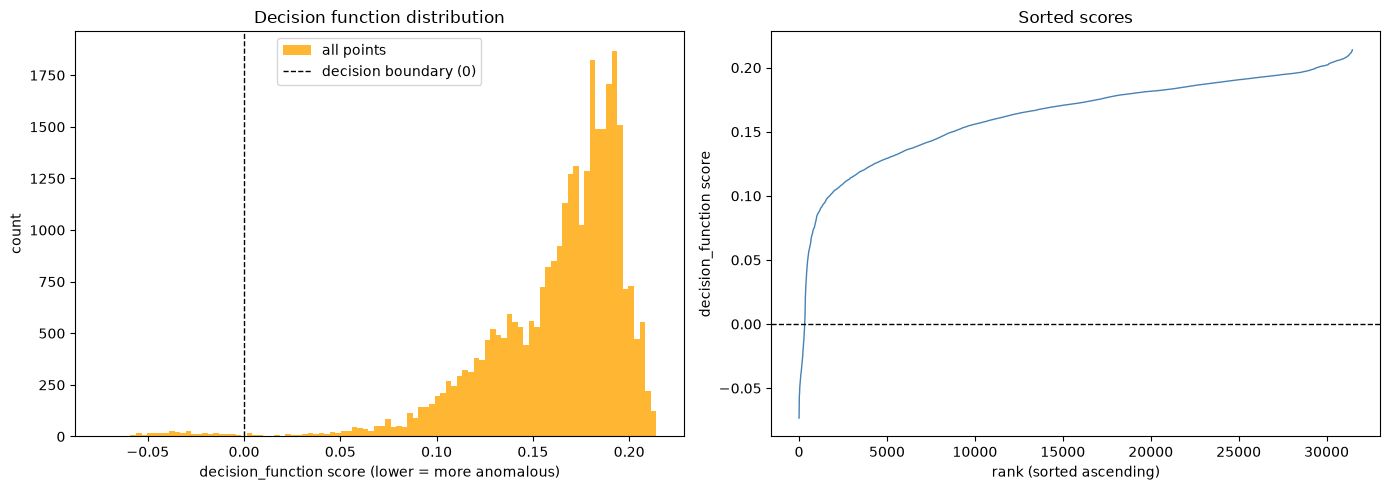

n points               : 31466
score min / max         : -0.0733 / 0.2140
score mean / std        : 0.1622 / 0.0376
   0.1th percentile     : -0.0527  (31 points below)
   0.5th percentile     : -0.0325  (157 points below)
     1th percentile     : 0.0000  (314 points below)
     2th percentile     : 0.0614  (629 points below)
     5th percentile     : 0.0977  (1573 points below)


array([0.02958027, 0.08361113, 0.07226179, ..., 0.12082521, 0.11552021,
       0.05514653], shape=(31466,))

In [14]:
from anomaly_detection.utils.score_diagnostics import run_diagnostics

run_diagnostics(security_model, X_security, known_anomaly_mask=None)

In [15]:
decision_scores = security_model.decision_function(X_security)

new_contamination = np.mean(decision_scores < 0.05)

new_contamination

np.float64(0.015604144155596517)

In [16]:
anomalies_df = results_df[results_df['prediction'] == -1]

anomalies_df

,day_cos,deltatime,month_sin,hour_sin,minute_cos,hour_cos,second_sin,month_cos,day_sin,minute_sin,...,permission,status,context,value,entity,actor,ip,process_id,anomaly_score,prediction
29,-0.222521,0 days 00:01:12.539443,1.224647e-16,0.000000,-0.207912,1.000000,6.691306e-01,-1.0,0.974928,0.978148,...,NaN,0x0,None,None,Administrateur,NaN,NaN,None,-0.656348,-1
33,-0.222521,0 days 00:00:09.495784,1.224647e-16,0.000000,-0.207912,1.000000,-3.090170e-01,-1.0,0.974928,0.978148,...,Negotiate,NaN,5,None,S-1-5-18,S-1-5-18,-,None,-0.681263,-1
216,-0.222521,0 days 00:01:07.388262,1.224647e-16,0.000000,-0.587785,1.000000,9.135455e-01,-1.0,0.974928,0.809017,...,NaN,0x0,None,None,Administrateur,NaN,NaN,None,-0.652120,-1
246,-0.222521,0 days 00:00:19.726685,1.224647e-16,0.000000,-0.669131,1.000000,5.665539e-16,-1.0,0.974928,0.743145,...,NaN,NaN,None,"<?xml version=""1.0"" encoding=""UTF-16""?>\r\n<Ta...",\Microsoft\Windows\WindowsUpdate\Scheduled Start,S-1-5-18,NaN,860,-0.715315,-1
427,-0.222521,0 days 00:01:21.969730,1.224647e-16,0.000000,-0.951057,1.000000,-3.090170e-01,-1.0,0.974928,0.309017,...,Negotiate,NaN,5,None,S-1-5-18,S-1-5-18,-,None,-0.698621,-1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
31304,-0.222521,0 days 00:00:01.557552,1.224647e-16,0.707107,0.309017,-0.707107,-9.135455e-01,-1.0,0.974928,-0.951057,...,NaN,NaN,None,,\CreateExplorerShellUnelevatedTask,S-1-5-21-3073298170-276159943-2983424533-500,NaN,None,-0.684919,-1
31305,-0.222521,0 days 00:00:00.039781,1.224647e-16,0.707107,0.309017,-0.707107,-9.135455e-01,-1.0,0.974928,-0.951057,...,NaN,NaN,None,"<?xml version=""1.0"" encoding=""UTF-16""?>\r\n<Ta...",\CreateExplorerShellUnelevatedTask,S-1-5-21-3073298170-276159943-2983424533-500,NaN,None,-0.692144,-1
31306,-0.222521,0 days 00:00:00.397790,1.224647e-16,0.707107,0.309017,-0.707107,-9.510565e-01,-1.0,0.974928,-0.951057,...,Negotiate,NaN,5,None,S-1-5-18,S-1-5-18,-,None,-0.656109,-1
31309,-0.222521,0 days 00:00:04.371983,1.224647e-16,0.707107,0.309017,-0.707107,-9.945219e-01,-1.0,0.974928,-0.951057,...,Negotiate,NaN,5,None,S-1-5-18,S-1-5-18,-,None,-0.658028,-1


In [17]:
with pd.option_context('display.max_rows', None, 'display.max_columns', None):
    print(anomalies_df['event_id'].value_counts())

event_id
4624    130
4799     95
4702     49
5379     17
4697     11
4798      4
4776      3
4662      1
5058      1
5061      1
5059      1
4699      1
4698      1
Name: count, dtype: int64


In [18]:
# Extract samples from each anomalous event ID
def pick_security_samples(n_samples_per_event):
    for event_id, group in anomalies_df.groupby("event_id"):
        print(f"\n{'=' * 60}")
        print(f"EventID {event_id}  --  {len(group)} anomalous rows")
 
        idx_min, idx_max = group.index.min(), group.index.max()
        idx_span = idx_max - idx_min
        print(f"row-index range: {idx_min} -> {idx_max}  (span: {idx_span})")
        print(f"{'=' * 60}")
 
        sample = group.sort_values("anomaly_score").head(n_samples_per_event)
 
        for idx, row in sample.iterrows():
            print(f"\n  row index:        {idx}")
            print(f"  event_record_id:  {row['event_record_id']}")
            print(f"  anomaly_score:    {row['anomaly_score']:.4f}")
 
            for col in [
                "event_id",
                "previous_event_id",
                "event_id_frequency",
                "version",
                "correlation_activity_id",
                "execution_thread_id",
            ]:
                if col in row and pd.notna(row[col]):
                    val = str(row[col])[:300]
                    print(f"  {col:<16}: {val}")
 
            for col in [
                "context",
                "process_name",
                "permission",
                "entity",
                "actor",
                "ip",
                "logon_id",
                "value",
                "process_id",
                "status",
            ]:
                if col in row and pd.notna(row[col]):
                    val = str(row[col])[:300]
                    print(f"  {col:<16}: {val}")

In [19]:
from contextlib import redirect_stdout

with open(output_path / 'anomalous_samples.txt', 'w') as f:
    with redirect_stdout(f):
        pick_security_samples(5)